# HHI Experiments: Survival-Adjusted Concentration Under Amortization Schedules

We track the **survival-adjusted Herfindahl-Hirschman Index**:

$$\text{HHI}^{\text{surv}}(t) = \sum_{j=1}^{J}
  \left(\frac{\sum_{A:\,\tau^A > t} w^{Aj}}{N^{\text{surv}}(t)}\right)^2
  = \sum_j \left(\bar{W}_j^{\text{surv}}(t)\right)^2$$

Since all obligors share the same principal $P$ and the same schedule type
within each experiment, $E^A(t)$ cancels out of numerator and denominator.
HHI^surv is therefore **purely a statement about the sectoral composition of
the surviving pool** — it is piecewise-constant and jumps only at each default
event $T_n$.

The mechanism connecting amortization to HHI is indirect but real:
smaller contagion jumps (amortizing schedules) → weaker feedback into the
dominant sector's intensity → less clustered defaults in that sector →
slower / smaller HHI trajectory. We test this across Bullet, Linear, and
French schedules under all three sector configurations.

In [ ]:
import numpy as np
import scipy
from scipy.stats import ncx2
from scipy.special import hyp1f1
from scipy.optimize import brentq
from math import exp
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pandas as pd
from scipy.stats import kurtosis
from pathlib import Path

DECIMALS = 6

np.set_printoptions(precision=DECIMALS, suppress=True)
pd.options.display.float_format = lambda x: f"{x:.{DECIMALS}f}"
pd.set_option("display.precision", DECIMALS)

matplotlib.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Computer Modern Roman', 'Times New Roman', 'Times'],
    'font.size': 10,
    'axes.labelsize': 11,
    'axes.titlesize': 12,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
    'figure.figsize': (6.0, 4.0),
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.05,
    'lines.linewidth': 1.5,
    'axes.linewidth': 0.8,
    'grid.linewidth': 0.5,
    'grid.alpha': 0.3,
    'axes.grid': False,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'text.usetex': False,
    'mathtext.fontset': 'cm',
})

IMG_DIR = Path("../images/peak_intensity")
IMG_DIR.mkdir(parents=True, exist_ok=True)

COLORS = {
    'hist': '#5B8DB8',
    'kde': '#C0392B',
    'dark': '#2C3E50',
    'green': '#27AE60',
    'purple': '#8E44AD',
    'gold': '#D4AC0D',
    'scatter': '#5B8DB8',
    'bar': '#5B8DB8',
}

In [2]:
def lambda_max_generator(epsilon, y, theta, sigma, kappa, max_attempts=5, tol=1e-8):
    """
    
    Compute H^*_epsilon such that P_y(sigma_H < tau) = G_y(H; H) <= epsilon.
    This function implements Equation (11) using the closed-form in Equation (19).

    """

    def G_y(H):

        a = H / kappa  # Now using H as the Laplace exponent (since tau ~ Exp(H))
        b = 2 * kappa * theta / sigma**2
        z_y = 2 * kappa * y / sigma**2
        z_H = 2 * kappa * H / sigma**2

        num = hyp1f1(a, b, z_y)
        denom = hyp1f1(a, b, z_H)
        
        return num / denom  # This is G_y(H; H) = E[e^{-H * sigma_H}]

    def root_function(H):
        return G_y(H) - epsilon

    # Bracketing interval
    H_min = y + 1e-8
    H_max = y + 10.0

    # Expand H_max until G_y(H_max) < epsilon
    for _ in range(max_attempts):
        try:
          H_star = scipy.optimize.toms748(root_function, H_min, H_max, xtol=tol)
          
          if root_function(H_star)<=0:
            
            return H_star
          
          else:
          
            while root_function(H_star)>0:
              H_star = H_star + 1e-2
          
            return H_star
          
        except Exception:
            pass
        
        H_max += 5.0

    # Fallback: scan manually to find conservative H
    print("[Warning] brentq failed to converge. Using fallback grid search.")
    H_vals = np.linspace(H_min, H_max + 50, 1000)
    for H in H_vals:
        if G_y(H) <= epsilon:
            return H

    raise RuntimeError("Unable to find H^*_epsilon. Try expanding search space.")


In [3]:
def cir_transition_sample_per_sector(y_vec, tau, kappa_vec, theta_vec, sigma_vec, rng):
    """
    y_vec, kappa_vec, theta_vec, sigma_vec are arrays of length J (sectors).
    Returns xi_vec: sampled Y_{t+tau} per sector (length J).
    """
    if tau <= 0:
        return y_vec.copy()
    
    one_minus = -np.expm1(-kappa_vec * tau)  # = 1 - exp(-kappa*tau)
    # avoid zeros
    one_minus = np.where(one_minus <= 0, 1e-16, one_minus)
    
    c = (sigma_vec * sigma_vec * one_minus) / (4.0 * kappa_vec)
    d = 4.0 * kappa_vec * theta_vec / (sigma_vec * sigma_vec)
    
    # noncentrality parameters
    nc = (4.0 * kappa_vec * np.exp(-kappa_vec * tau) * y_vec) / (sigma_vec * sigma_vec * one_minus)
    
    # guard
    d = np.maximum(d, 1e-12)
    nc = np.maximum(nc, 0.0)
    
    # sample per sector (simple looping works fine since J would be typically small)
    xi = np.empty_like(y_vec, dtype=float)

    for j in range(len(y_vec)):
    
        # If df or nc are extreme, ncx2.rvs might throw an error
        try:
            Z = ncx2.rvs(df=d[j], nc=nc[j], random_state=rng)
    
        except Exception:
            Z = ncx2.rvs(df=max(d[j],1e-6), nc=0.0, random_state=rng) + nc[j]
    
        xi[j] = c[j] * Z
    
    xi = np.maximum(xi, 0.0)
    
    return xi


In [4]:
from scipy.interpolate import interp1d

def loss_distribution_plot(Payoff_T,index):
  # Get histogram data (without plotting)
  counts, bin_edges = np.histogram(Payoff_T, bins=10, density=True)

  # Get bin centers
  bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

  # Interpolation function
  f_interp = interp1d(bin_centers, counts, kind='cubic', fill_value="extrapolate")

  # New x-values for smooth curve
  x_smooth = np.linspace(bin_centers.min(), bin_centers.max(), 500)
  y_smooth = f_interp(x_smooth)

  # Plot histogram and interpolated curve
  plt.hist(Payoff_T, bins=100, density=True, label='Histogram_'+str(index),alpha = 0.4)
  plt.plot(x_smooth, y_smooth, label='Loss Distribution Case_'+str(index))
  plt.xlabel('Loss')
  plt.ylabel('Density')
  # plt.legend()


In [5]:
def expected_shortfall(losses, alpha=0.95):
    var_alpha = np.quantile(losses, alpha)
    tail_losses = losses[losses >= var_alpha]
    return float(np.round(tail_losses.mean(), DECIMALS))

def compute_metrics(losses, alpha=0.95):
    var_alpha = np.quantile(losses, alpha)
    es = expected_shortfall(losses, alpha)
    metrics = {
        "Mean": np.mean(losses),
        "Std": np.std(losses),
        "VaR": var_alpha,
        "ES": es,
        "Excess ES": es - var_alpha,
        "ExcessKurtosis": kurtosis(losses)
    }
    return {key: float(np.round(value, DECIMALS)) for key, value in metrics.items()}

In [6]:
loan_types = ["bullet", "linear", "french", "negative"]

def bullet_exposure(contract, T, t):
    P = float(contract["P"])
    return P if t < T else 0.0


def linear_exposure(contract, T, t):
    P = float(contract["P"])
    periods_per_year = float(contract["N"])
    if periods_per_year <= 0 or T <= 0:
        return 0.0

    period = 1.0 / periods_per_year  # years per period
    total_periods = int(np.ceil(T * periods_per_year))
    payments_made = int(np.floor(t / period))
    payments_made = int(np.clip(payments_made, 0, total_periods))
    principal_paid = (payments_made / total_periods) * P
    return max(P - principal_paid, 0.0)


def french_exposure(contract, T, t):
    P = float(contract["P"])
    periods_per_year = float(contract["N"])
    r_annual = float(contract["r"])
    if periods_per_year <= 0 or T <= 0:
        return 0.0

    period = 1.0 / periods_per_year  # years per period
    total_periods = int(np.ceil(T * periods_per_year))
    payments_made = int(np.floor(t / period))
    payments_made = int(np.clip(payments_made, 0, total_periods))
    periods_remaining = total_periods - payments_made
    if periods_remaining <= 0:
        return 0.0

    r_period = r_annual / periods_per_year  # annual to per-period rate

    if r_period == 0.0:
        payment = P / total_periods
        return payment * periods_remaining

    annuity_payment = P * r_period / (1.0 - (1.0 + r_period) ** (-total_periods))
    pv_remaining = annuity_payment * (1.0 - (1.0 + r_period) ** (-periods_remaining)) / r_period
    return pv_remaining


def negative_amortization_exposure(contract, T, t):
    P = float(contract["P"])
    periods_per_year = float(contract["N"])
    r_annual = float(contract.get("r", 0.0))
    if periods_per_year <= 0 or T <= 0:
        return max(P, 0.0)

    period = 1.0 / periods_per_year  # years per period
    total_periods = int(np.ceil(T * periods_per_year))
    periods_elapsed = int(np.floor(t / period))
    periods_elapsed = int(np.clip(periods_elapsed, 0, total_periods))

    r_period = r_annual / periods_per_year  # annual to per-period rate

    exposure = P * ((1.0 + r_period) ** periods_elapsed)

    return exposure if t < T else 0.0


def exposure_at_time(contract, T, t):
    loan_type = str(contract["type"]).lower()
    dispatch = {
        "bullet": bullet_exposure,
        "linear": linear_exposure,
        "french": french_exposure,
        "negative_amortisation": negative_amortization_exposure,
    }
    if loan_type not in dispatch:
        raise ValueError(f"Unknown loan type: {loan_type}")
    return dispatch[loan_type](contract, T, t)


In [7]:
def simulate_sector_cir_model(kappa, theta, sigma, T, delta, W, eps, lambda_benchmark,
                              Nfirms, idiosyncratic_factor, loan_contracts, rng=None):

    import warnings

    if rng is None:
        rng = np.random.default_rng()

    # ensure shapes
    J = len(theta)
    assert W.shape == (Nfirms, J)
    idiosyncratic_factor = np.asarray(idiosyncratic_factor).reshape(Nfirms,)
    lambda_benchmark = np.asarray(lambda_benchmark).reshape(J,)

    delta = np.asarray(delta)
    if delta.ndim == 1:
        delta = np.tile(delta.reshape(1, J), (Nfirms, 1))
    assert delta.shape == (Nfirms, J)

    # init
    t = 0.0
    Y_t = theta.copy().astype(float)   # sectoral intensities (J-vector), initialised at theta
    events = []
    owed = []
    marks = []
    defaulter_idio_factor = []
    sector_contributions = []
    alive = np.arange(Nfirms, dtype=int)
    defaulter_indices   = []

    # precompute some arrays for speed
    kappa = np.asarray(kappa, dtype=float)
    sigma = np.asarray(sigma, dtype=float)
    theta = np.asarray(theta, dtype=float)

    # event loop
    while (t < T) and (alive.size > 0):

        lambda_max = np.maximum(Y_t, lambda_benchmark)  # J-vector
        # Hepsilon = sum_i [ X_i + w_i · lambda_max ] over alive firms
        
        # We can compute per-firm value and sum
        per_firm_sys = W[alive].dot(lambda_max)   # length alive.size
        per_firm_idio = idiosyncratic_factor[alive]
        Hepsilon = per_firm_sys.sum() + per_firm_idio.sum()

        if Hepsilon <= 0:
            break

        # sample a candidate waiting time
        tau = rng.exponential(1.0 / Hepsilon)
        t_candidate = t + tau
        if t_candidate >= T:
            break

        # sample sectoral Y at t_candidate conditional on no defaults in the waiting time
        Y_proposed = cir_transition_sample_per_sector(Y_t, tau, kappa, theta, sigma, rng)

        # compute proposed per-firm intensities (scalar values) using Y_proposed
        per_firm_sys_prop = W[alive].dot(Y_proposed)
        per_firm_total_prop = per_firm_sys_prop + per_firm_idio
        lambda_proposed_total = per_firm_total_prop.sum()

        # acceptance probability: Xi / Hepsilon where Xi = lambda_proposed_total
        accept_prob = min(lambda_proposed_total / Hepsilon, 1.0)
        if rng.random() < accept_prob:
            # accept a default at t_candidate
            t = t_candidate
            events.append(t)

            # choose which alive firm defaulted
            probs = per_firm_total_prop / lambda_proposed_total
            probs = np.maximum(probs, 0.0)
            probs = probs / probs.sum()
            selected_local_idx = rng.choice(len(alive), p=probs)
            selected_firm = int(alive[selected_local_idx])
            defaulter_indices.append(selected_firm)

            # record idiosyncratic factor
            defaulter_idio_factor.append(float(idiosyncratic_factor[selected_firm]))

            sector_contributions.append(W[selected_firm].copy())

            # mark (loss) from contract exposure
            contract = loan_contracts[selected_firm]
            exposure = exposure_at_time(contract, T, t)
            if exposure < 0:
                warnings.warn("Exposure computed negative; clamping to zero.")
                exposure = max(exposure, 0.0)
            if t >= T and exposure > 0:
                warnings.warn("Exposure positive after maturity; forcing to zero.")
                exposure = 0.0

            owed.append(exposure)
            
            LGD = rng.uniform(0,1)
            mark = LGD * exposure
            mark =  exposure
            if mark < 0:
                warnings.warn("Loss mark negative; clamping to zero.")
                mark = max(mark, 0.0)
            marks.append(mark)

            # update Y_t with contagion
            Y_t = Y_proposed + delta[selected_firm] * mark/contract["P"]

            # remove defaulted firm from alive set
            alive = np.delete(alive, selected_local_idx)

        else:
            # reject, ie no default: advance time and set Y_t = Y_proposed
            t = t_candidate
            Y_t = Y_proposed

    return (np.array(events), np.array(marks), np.array(owed),
            np.array(defaulter_idio_factor), np.array(sector_contributions),
            np.array(defaulter_indices, dtype=int))

In [8]:
def generate_portfolio_weights(N, J, composition_type, concentration_params=None, rng=None):
    """
    Build portfolio weights under three stylised configurations plus a random fallback.

    - concentrated: one dominant sector for every obligor (eg for J=3 [0.7, 0.2, 0.1])
    - balanced: evenly distributed across sectors (eg for J=3  [1/3, 1/3, 1/3])
    - mixed: partial concentration with residual diversified weights (eg for J=3  [0.5, 0.3, 0.2])
    - random: symmetric Dirichlet for variation.
    """
    if rng is None:
        rng = np.random.default_rng()

    if concentration_params is None:
        concentration_params = {}

    noise_level = concentration_params.get("noise_level", 0.0)
    alpha_random = concentration_params.get("alpha", 1.0)

    if composition_type == "concentrated":
        pattern = _pattern_concentrated(J)
        W = _apply_noise_and_normalize(pattern, N, noise_level, rng)
    elif composition_type == "balanced":
        pattern = _pattern_balanced(J)
        W = _apply_noise_and_normalize(pattern, N, noise_level, rng)
    elif composition_type == "mixed":
        pattern = _pattern_mixed(J)
        W = _apply_noise_and_normalize(pattern, N, noise_level, rng)
    elif composition_type == "random":
        W = _generate_random_weights(N, J, {"alpha": alpha_random}, rng)
    else:
        raise ValueError(f"Unknown composition_type: {composition_type}")

    return W


def _pattern_concentrated(J, dominant=0.7):
    if J <= 0:
        return np.array([])
    if J == 1:
        return np.array([1.0])
    residual = max(1.0 - dominant, 0.0)
    tail = residual / (J - 1)
    vec = np.full(J, tail)
    vec[0] = dominant
    return vec


def _pattern_balanced(J):
    if J <= 0:
        return np.array([])
    return np.full(J, 1.0 / J)


def _pattern_mixed(J, primary=0.5, secondary=0.3):
    if J <= 0:
        return np.array([])
    vec = np.zeros(J)
    vec[0] = min(primary, 1.0)
    if J >= 2:
        vec[1] = min(secondary, max(1.0 - vec[0], 0.0))
    residual = max(1.0 - vec.sum(), 0.0)
    if J > 2:
        vec[2:] = residual / (J - 2)
    elif J == 1:
        vec[0] = 1.0
    else:
        vec[1] += residual
    return vec


def _apply_noise_and_normalize(pattern, N, noise_level, rng):
    base = np.tile(pattern, (N, 1))
    if noise_level > 0:
        noise = rng.normal(0.0, noise_level, size=base.shape)
        base = base + noise
    base = np.maximum(base, 1e-6)
    base = base / base.sum(axis=1, keepdims=True)
    return base


def _generate_random_weights(N, J, params, rng):
    alpha = params.get("alpha", 1.0)
    W = np.zeros((N, J))
    for i in range(N):
        W[i] = rng.dirichlet(np.full(J, alpha))
    return W

In [9]:
def run_simulation(params, loan_contracts, num_trials, seed=42):

    rng = np.random.default_rng(seed)
    eps = 1e-5
    losses = np.zeros(num_trials)
    for i in range(num_trials):
        events, marks, _, _, _, d_indices = simulate_sector_cir_model(params['kappa'], params['theta'], params['sigma'], 
                          params['T'], params['delta'], params['W'], 1e-5, 
                          params['lambda_benchmark'], 
                          params['Firms'], params['idio_factor'], 
                          loan_contracts,
                          rng)
        losses[i] = np.sum(marks)
    return losses

## HHI trajectory computation (per path)

Given the initial weight matrix $W$ (N × J) and the ordered list of defaulting firm indices with their default times, we reconstruct $\text{HHI}^{\text{surv}}(t)$ on any supplied time grid.



In [10]:
def compute_hhi_trajectory(W_init, defaulter_indices, event_times, time_grid):
    """
    Compute HHI^surv on time_grid for a single simulated path.
 
    Parameters
    W_init           : (N, J) array  – initial sector weights for all firms
    defaulter_indices: (D,) int array – firm indices in default order
    event_times      : (D,) float array – corresponding default times
    time_grid        : (G,) float array – evaluation points (must be sorted)
 
    returns
    hhi : (G,) float array
        HHI^surv at each point in time_grid.
        Set to np.nan when all firms have defaulted.
    """
    N, J          = W_init.shape
    sector_sums   = W_init.sum(axis=0).copy()   # sum of w^{Aj} over all survivors
    n_alive       = N
    ptr           = 0                            # pointer into event_times
    n_events      = len(event_times)
 
    hhi = np.empty(len(time_grid))
 
    for i, t in enumerate(time_grid):
        # advance pointer: process every default that happened at or before t
        while ptr < n_events and event_times[ptr] <= t:
            firm          = defaulter_indices[ptr]
            sector_sums  -= W_init[firm]
            n_alive      -= 1
            ptr          += 1
 
        if n_alive <= 0:
            hhi[i] = np.nan
        else:
            w_bar  = sector_sums / n_alive          # average sector weight among survivors
            hhi[i] = float(np.dot(w_bar, w_bar))  
 
    return hhi


In [ ]:
def run_hhi_simulation(params, loan_contracts, num_trials, time_grid, seed=42):

    rng  = np.random.default_rng(seed)
    W    = params['W']
    T    = params['T']
    G    = len(time_grid)
 
    losses           = np.zeros(num_trials)
    hhi_trajectories = np.zeros((num_trials, G))
 
    for i in range(num_trials):
        events, marks, _, _, _, d_indices = simulate_sector_cir_model(
            params['kappa'], params['theta'], params['sigma'],
            T, params['delta'], W, 1e-5,
            params['lambda_benchmark'],
            params['Firms'], params['idio_factor'],
            loan_contracts, rng)
 
        losses[i]              = float(np.sum(marks))
        hhi_trajectories[i]    = compute_hhi_trajectory(
                                            W, d_indices, events, time_grid)
 
    return losses, hhi_trajectories

## Experiment parameters

N=1000 obligors,
J=3 sectors, 
T=1, 
c=0.01, 
2500 MC paths.

Loan parameters: P=10, r=0.12, Np=12 

In [12]:
MASTER_SEED  = 42
NUM_TRIALS   = 2500
N_FIRMS      = 1000
J_SECTORS    = 3
T_HORIZON    = 1.0
SENSITIVITY  = 0.01          
ALPHA_ES     = 0.95
 

time_grid = np.linspace(0.0, T_HORIZON, 201) # exclude 0 so that initial HHI is well-defined
 

rng_setup = np.random.default_rng(MASTER_SEED)
 
kappa_vec = rng_setup.uniform(0.5,  1.5,  J_SECTORS)
theta_vec = rng_setup.uniform(0.001, 0.051, J_SECTORS)
raw_sigma = rng_setup.uniform(0.0,  0.2,  J_SECTORS)
sigma_vec = np.minimum(np.sqrt(2 * kappa_vec * theta_vec), raw_sigma)
sigma_vec = np.maximum(sigma_vec, 1e-6)
 
lambda_benchmark = kappa_vec.copy()      
 

idio_factor = rng_setup.uniform(0.01, 0.03, N_FIRMS)
 
LOAN_P  = 10.0
LOAN_r  = 0.12
LOAN_Np = 12
 
loan_contract_templates = {
    "bullet": {"type": "bullet",  "P": LOAN_P, "r": LOAN_r, "N": LOAN_Np},
    "linear": {"type": "linear",  "P": LOAN_P, "r": LOAN_r, "N": LOAN_Np},
    "french": {"type": "french",  "P": LOAN_P, "r": LOAN_r, "N": LOAN_Np},
}
SCHEDULES = list(loan_contract_templates.keys())
 
CONFIGS = ["concentrated", "balanced", "mixed"]
 
CONFIG_LABELS = {
    "concentrated": "Concentrated (0.70 / 0.20 / 0.10)",
    "balanced":     "Balanced (0.33 / 0.33 / 0.33)",
    "mixed":        "Mixed (0.50 / 0.30 / 0.20)",
}
 
SCHEDULE_LABELS = {
    "bullet": "Bullet",
    "linear": "Linear",
    "french": "French",
}
 
SCHEDULE_COLORS = {"bullet": "#1f77b4", "linear": "#2ca02c", "french": "#ff7f0e"}
SCHEDULE_LS     = {"bullet": "-",       "linear": "-",        "french": "--"}
 

W_matrices = {}
for cfg in CONFIGS:
    W_matrices[cfg] = generate_portfolio_weights(
        N_FIRMS, J_SECTORS, cfg, rng=np.random.default_rng(MASTER_SEED + 1))
 

def make_delta(W, c):
    return c * W      
 
print("Parameters set.  Runs to execute:", len(CONFIGS) * len(SCHEDULES))
print(f"  kappa : {np.round(kappa_vec, 4)}")
print(f"  theta : {np.round(theta_vec, 4)}")
print(f"  sigma : {np.round(sigma_vec, 4)}")

Parameters set.  Runs to execute: 9
  kappa : [1.274  0.9389 1.3586]
  theta : [0.0359 0.0057 0.0498]
  sigma : [0.1522 0.1035 0.0256]


In [13]:
results = {}
 
for cfg in CONFIGS:
    results[cfg] = {}
    W = W_matrices[cfg]
 
    for sched in SCHEDULES:
        contracts = [dict(loan_contract_templates[sched]) for _ in range(N_FIRMS)]
 
        params = dict(
            kappa           = kappa_vec,
            theta           = theta_vec,
            sigma           = sigma_vec,
            T               = T_HORIZON,
            delta           = make_delta(W, SENSITIVITY),
            W               = W,
            lambda_benchmark = lambda_benchmark,
            Firms           = N_FIRMS,
            idio_factor     = idio_factor,
        )
 
        seed_i = MASTER_SEED + CONFIGS.index(cfg) * 10 + SCHEDULES.index(sched)
        losses, hhi = run_hhi_simulation(
            params, contracts, NUM_TRIALS, time_grid, seed=seed_i)
 
        results[cfg][sched] = {"losses": losses, "hhi": hhi}
        print(f"  [{cfg:12s} | {sched:6s}]  mean loss = {losses.mean():.2f} "
              f"  ES95 = {expected_shortfall(losses):.2f}")
 
print("\nAll runs complete.")

  [concentrated | bullet]  mean loss = 4716.46   ES95 = 6301.85
  [concentrated | linear]  mean loss = 987.08   ES95 = 1606.26
  [concentrated | french]  mean loss = 1036.09   ES95 = 1674.33
  [balanced     | bullet]  mean loss = 1995.17   ES95 = 2885.74
  [balanced     | linear]  mean loss = 567.31   ES95 = 874.48
  [balanced     | french]  mean loss = 583.49   ES95 = 903.28
  [mixed        | bullet]  mean loss = 2428.88   ES95 = 3624.88
  [mixed        | linear]  mean loss = 627.50   ES95 = 998.65
  [mixed        | french]  mean loss = 645.16   ES95 = 1036.81

All runs complete.


## Plot 1: Mean HHI^surv over time by schedule (one panel per config)

This shows the *average* trajectory of portfolio sectoral concentration as
defaults accumulate.  Under Bullet the dominant-sector obligors exit faster
(stronger contagion), so the surviving pool becomes less concentrated sooner.
Amortizing schedules should show a slower, flatter decline.

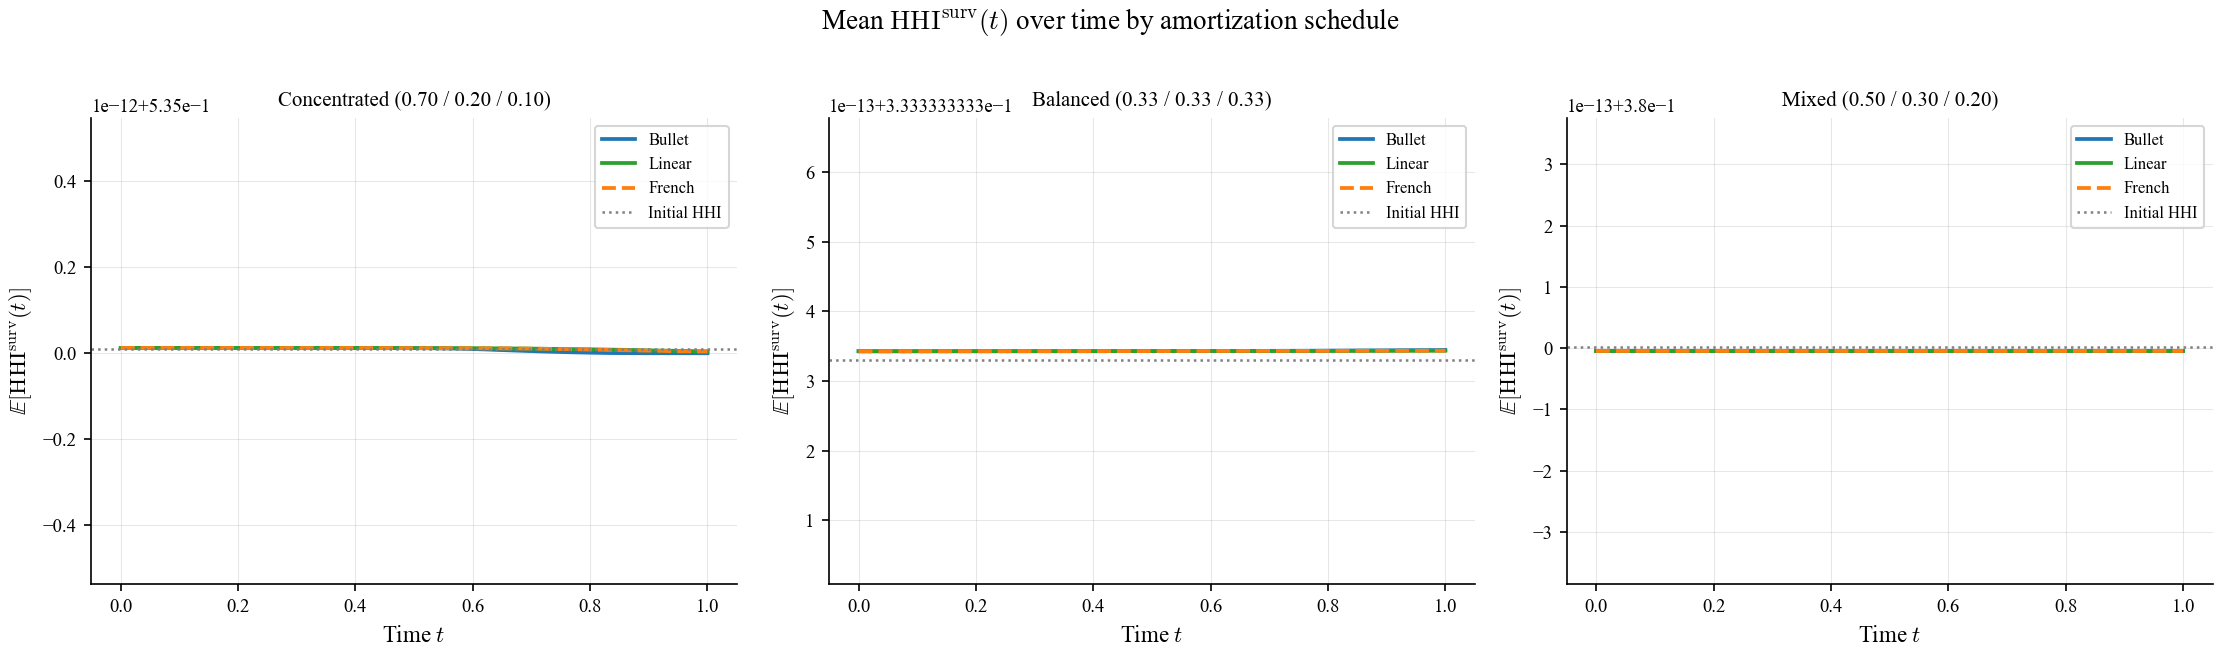

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=False)
fig.suptitle(r"Mean $\mathrm{HHI}^{\mathrm{surv}}(t)$ over time by amortization schedule",
             fontsize=13)
 
for ax, cfg in zip(axes, CONFIGS):
    W = W_matrices[cfg]
    w_bar_init = W.mean(axis=0)
    hhi_0 = float(np.dot(w_bar_init, w_bar_init))
 
    for sched in SCHEDULES:
        hhi_mat = results[cfg][sched]["hhi"]                  # (trials, grid)

        mean_hhi = np.nanmean(hhi_mat, axis=0)
        se_hhi   = np.nanstd(hhi_mat, axis=0) / np.sqrt(NUM_TRIALS)
 
        ax.plot(time_grid, mean_hhi,
                color=SCHEDULE_COLORS[sched],
                ls=SCHEDULE_LS[sched],
                lw=1.8,
                label=SCHEDULE_LABELS[sched])
        ax.fill_between(time_grid,
                        mean_hhi - 1.96 * se_hhi,
                        mean_hhi + 1.96 * se_hhi,
                        color=SCHEDULE_COLORS[sched], alpha=0.12)
 
    ax.axhline(hhi_0, color="gray", ls=":", lw=1.2, label="Initial HHI")
    ax.set_title(CONFIG_LABELS[cfg], fontsize=10)
    ax.set_xlabel("Time $t$")
    ax.set_ylabel(r"$\mathbb{E}[\mathrm{HHI}^{\mathrm{surv}}(t)]$")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
 
plt.tight_layout()
plt.savefig("hhi_mean_trajectories.pdf", bbox_inches="tight")
plt.show()

## Plot 2: HHI^surv path variance over time

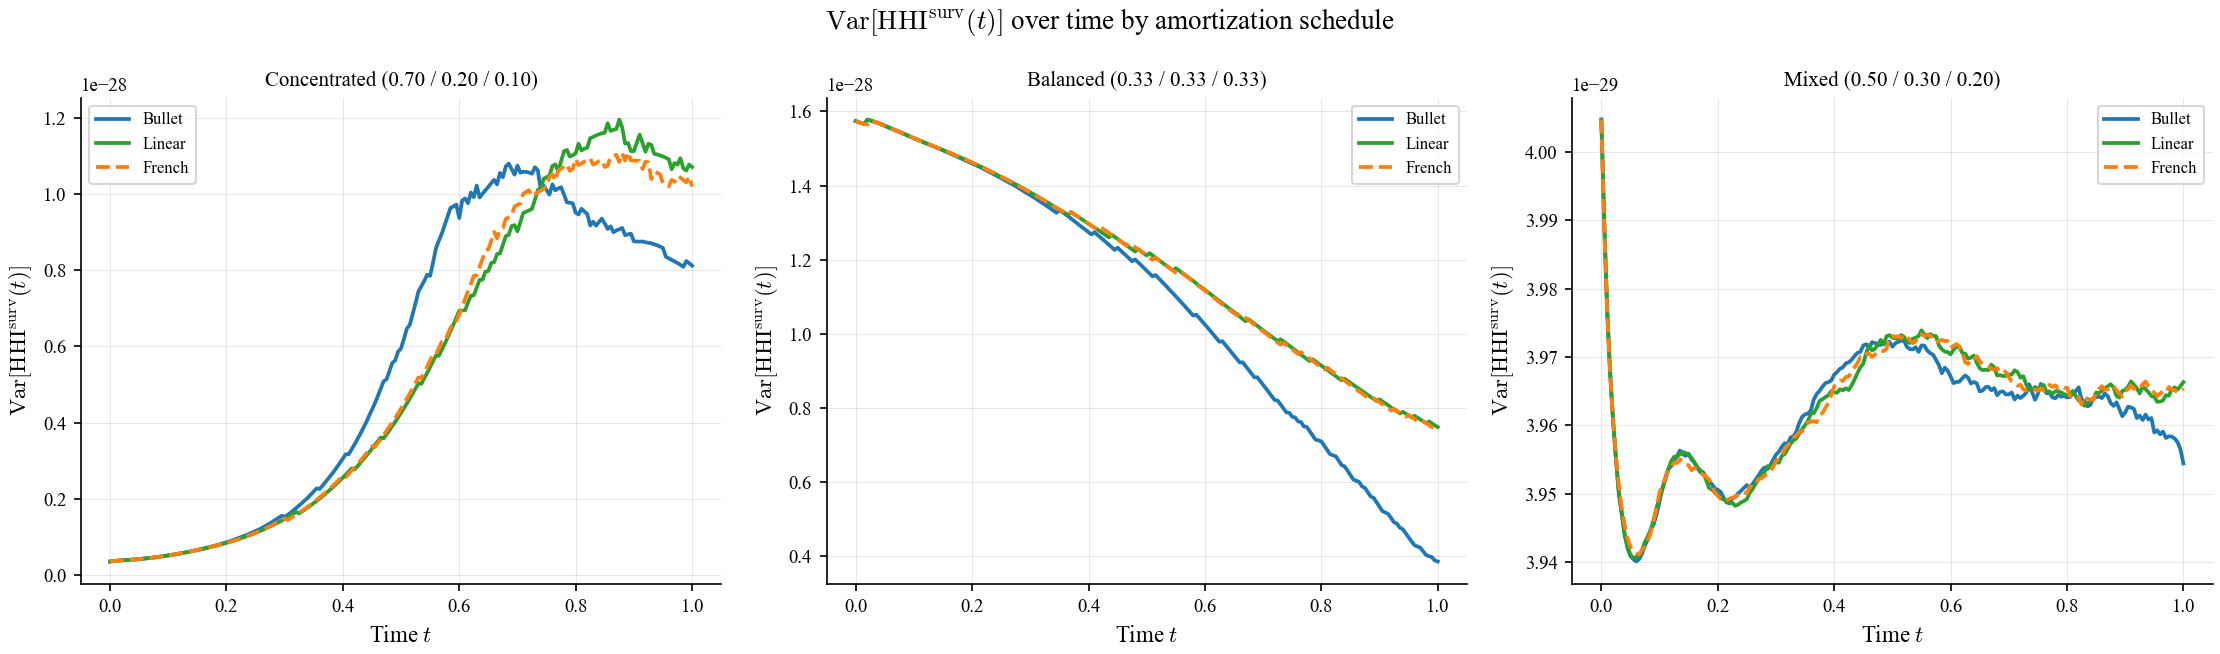

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=False)
fig.suptitle(r"$\mathrm{Var}[\mathrm{HHI}^{\mathrm{surv}}(t)]$ over time by amortization schedule",
             fontsize=13)
 
for ax, cfg in zip(axes, CONFIGS):
    for sched in SCHEDULES:
        hhi_mat  = results[cfg][sched]["hhi"]
        var_hhi  = np.nanvar(hhi_mat, axis=0)
 
        ax.plot(time_grid, var_hhi,
                color=SCHEDULE_COLORS[sched],
                ls=SCHEDULE_LS[sched],
                lw=1.8,
                label=SCHEDULE_LABELS[sched])
 
    ax.set_title(CONFIG_LABELS[cfg], fontsize=10)
    ax.set_xlabel("Time $t$")
    ax.set_ylabel(r"$\mathrm{Var}[\mathrm{HHI}^{\mathrm{surv}}(t)]$")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
 
plt.tight_layout()
plt.savefig("hhi_variance_trajectories.pdf", bbox_inches="tight")
plt.show()

## Plot 3: Tail vs non-tail conditioning (the key experiment)

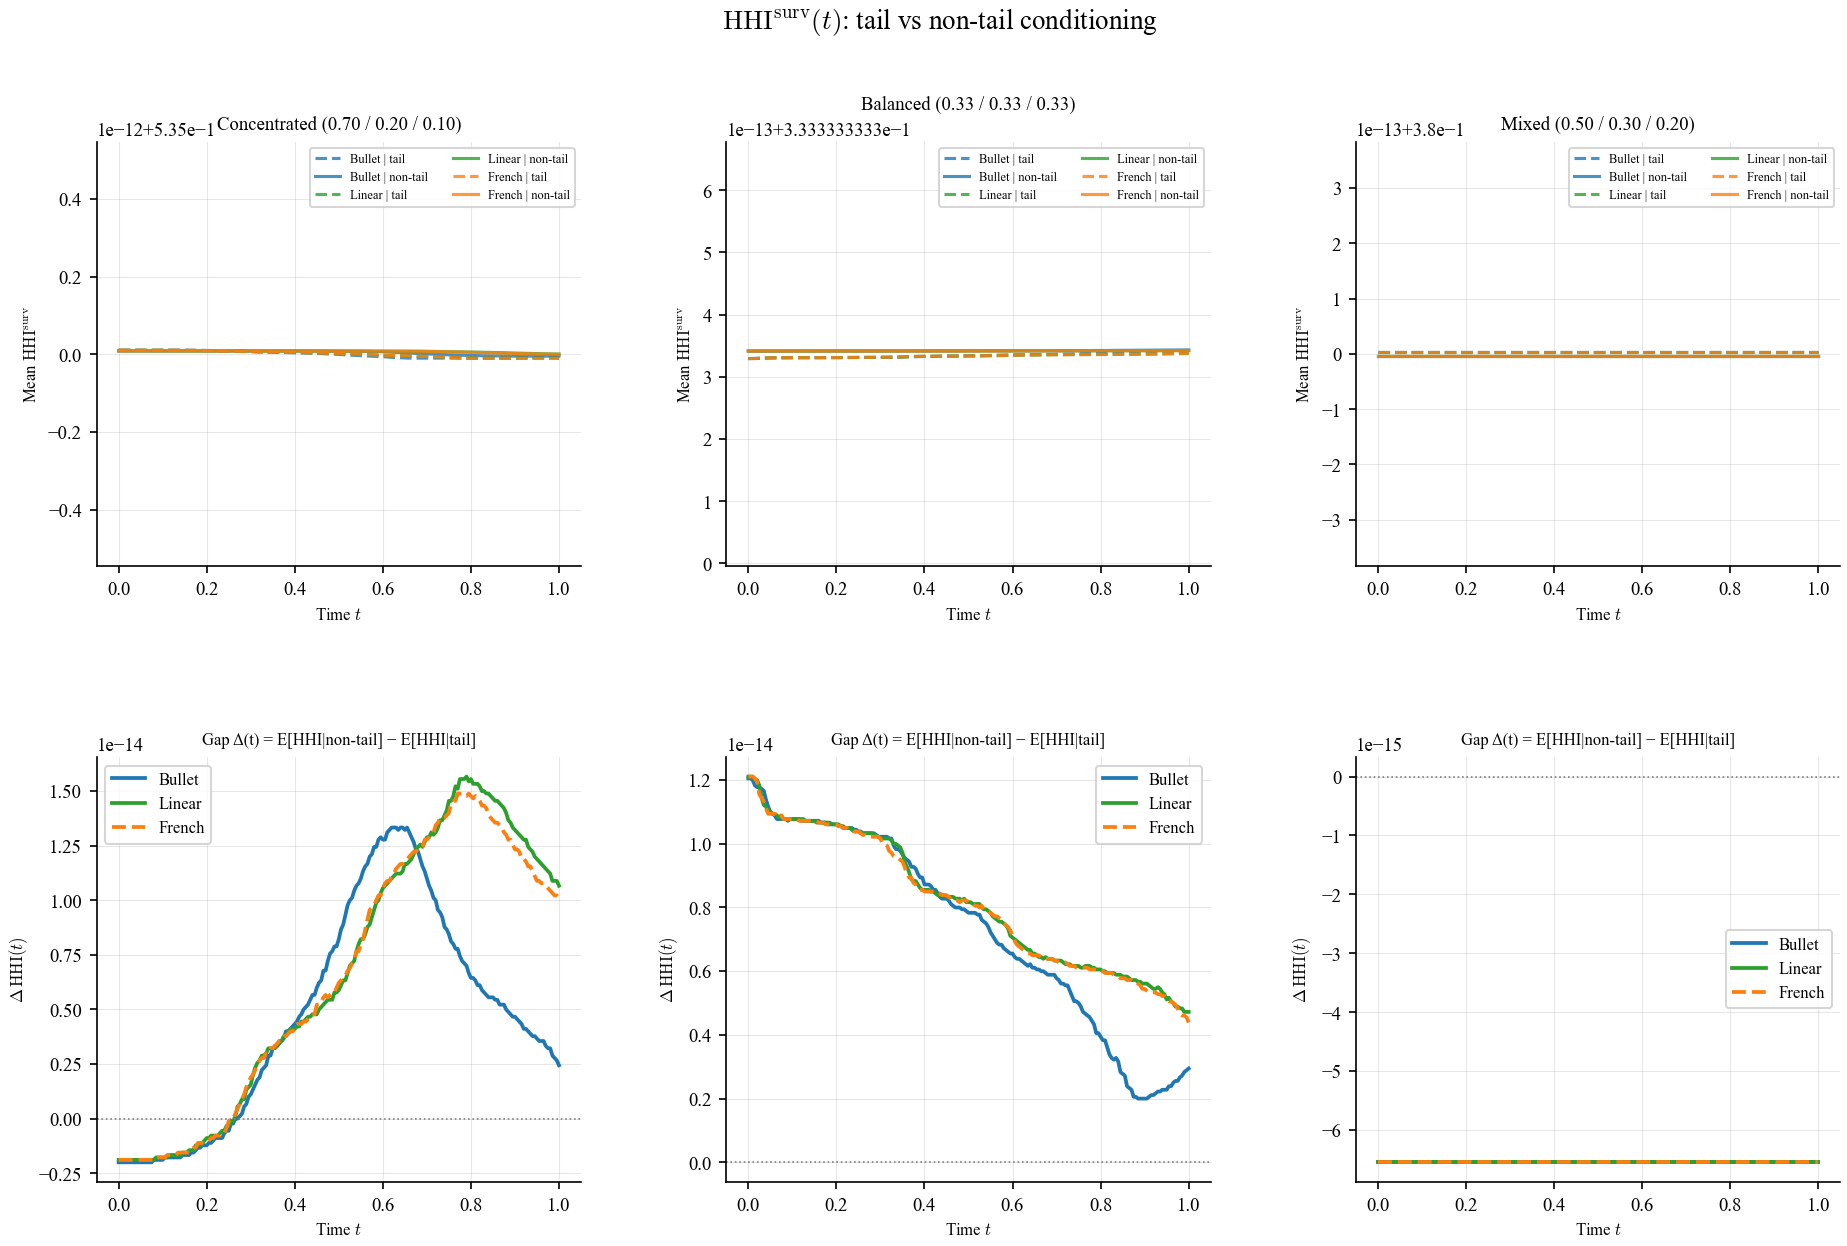

In [16]:
fig = plt.figure(figsize=(15, 9))
outer = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.3)
 
fig.suptitle(
    r"$\mathrm{HHI}^{\mathrm{surv}}(t)$: tail vs non-tail conditioning",
    fontsize=13)
 
for col, cfg in enumerate(CONFIGS):
    ax_top = fig.add_subplot(outer[0, col])
    ax_bot = fig.add_subplot(outer[1, col])
 
    for sched in SCHEDULES:
        hhi_mat = results[cfg][sched]["hhi"]
        losses  = results[cfg][sched]["losses"]
 
        var_alpha = np.quantile(losses, ALPHA_ES)
        tail_mask = losses >= var_alpha
 
        mean_tail     = np.nanmean(hhi_mat[tail_mask],      axis=0)
        mean_nontail  = np.nanmean(hhi_mat[~tail_mask],     axis=0)
        gap           = mean_nontail - mean_tail
 
        c  = SCHEDULE_COLORS[sched]
        ls = SCHEDULE_LS[sched]
        lbl = SCHEDULE_LABELS[sched]
 
        ax_top.plot(time_grid, mean_tail,    color=c, ls="--",  lw=1.5, alpha=0.8,
                    label=f"{lbl} | tail")
        ax_top.plot(time_grid, mean_nontail, color=c, ls="-",   lw=1.5, alpha=0.8,
                    label=f"{lbl} | non-tail")
        ax_bot.plot(time_grid, gap,          color=c, ls=ls,    lw=1.8,
                    label=lbl)
 
    ax_top.set_title(CONFIG_LABELS[cfg], fontsize=9)
    ax_top.set_xlabel("Time $t$", fontsize=8)
    ax_top.set_ylabel(r"Mean $\mathrm{HHI}^{\mathrm{surv}}$", fontsize=8)
    ax_top.legend(fontsize=6, ncol=2)
    ax_top.grid(True, alpha=0.3)
 
    ax_bot.axhline(0, color="gray", lw=0.8, ls=":")
    ax_bot.set_title(f"Gap Δ(t) = E[HHI|non-tail] − E[HHI|tail]", fontsize=8)
    ax_bot.set_xlabel("Time $t$", fontsize=8)
    ax_bot.set_ylabel(r"$\Delta\,\mathrm{HHI}(t)$", fontsize=8)
    ax_bot.legend(fontsize=8)
    ax_bot.grid(True, alpha=0.3)
 
plt.savefig("hhi_tail_conditioning.pdf", bbox_inches="tight")
plt.show()


In [ ]:
rows_loss = []
for cfg in CONFIGS:
    for sched in SCHEDULES:
        L = results[cfg][sched]["losses"]
        m = compute_metrics(L, alpha=ALPHA_ES)
        rows_loss.append({
            "Config":   cfg.capitalize(),
            "Schedule": sched.capitalize(),
            "Mean Loss": round(m["Mean"],      2),
            "Std Dev":   round(m["Std"],       2),
            "VaR 95%":   round(m["VaR"],       2),
            "ES 95%":    round(m["ES"],         2),
            "Excess ES": round(m["Excess ES"], 2),
        })
 
df_loss = pd.DataFrame(rows_loss).set_index(["Config", "Schedule"])
print("TABLE A — Portfolio Loss Metrics")
print(df_loss.to_string())
print()
 

# index for T/2 in the time grid
mid_idx = np.searchsorted(time_grid, T_HORIZON / 2.0)
 
rows_hhi = []
for cfg in CONFIGS:
    W        = W_matrices[cfg]
    w_bar_0  = W.mean(axis=0)
    hhi_init = float(np.dot(w_bar_0, w_bar_0))
 
    for sched in SCHEDULES:
        hhi_mat = results[cfg][sched]["hhi"]
        losses  = results[cfg][sched]["losses"]
 
        var_alpha  = np.quantile(losses, ALPHA_ES)
        tail_mask  = losses >= var_alpha
 
        hhi_terminal_all      = hhi_mat[:, -1]
        mean_terminal         = float(np.nanmean(hhi_terminal_all))
        std_terminal          = float(np.nanstd(hhi_terminal_all))
 
        mean_tail_mid    = float(np.nanmean(hhi_mat[tail_mask,    mid_idx]))
        mean_nontail_mid = float(np.nanmean(hhi_mat[~tail_mask,   mid_idx]))
        gap_mid          = mean_nontail_mid - mean_tail_mid
 
        rows_hhi.append({
            "Config":             cfg.capitalize(),
            "Schedule":           sched.capitalize(),
            "HHI (t=0)":          round(hhi_init,       4),
            "Mean HHI (t=T)":     round(mean_terminal,  4),
            "Std HHI (t=T)":      round(std_terminal,   4),
            "Δ(T/2) gap":         round(gap_mid,        4),
        })
 
df_hhi = pd.DataFrame(rows_hhi).set_index(["Config", "Schedule"])
print("TABLE B — HHI^surv Metrics")
print(df_hhi.to_string())
print()

TABLE A — Portfolio Loss Metrics
                        Mean Loss    Std Dev     VaR 95%      ES 95%  Excess ES
Config       Schedule                                                          
Concentrated Bullet   4716.460000 876.580000 6040.000000 6301.850000 261.850000
             Linear    987.080000 278.000000 1468.380000 1606.260000 137.880000
             French   1036.090000 287.610000 1533.950000 1674.330000 140.380000
Balanced     Bullet   1995.170000 422.320000 2720.000000 2885.740000 165.740000
             Linear    567.310000 134.150000  805.040000  874.480000  69.440000
             French    583.490000 139.830000  827.610000  903.280000  75.680000
Mixed        Bullet   2428.880000 560.720000 3380.500000 3624.880000 244.380000
             Linear    627.500000 162.670000  908.380000  998.650000  90.280000
             French    645.160000 168.220000  940.260000 1036.810000  96.550000

TABLE B — HHI^surv Metrics
                       HHI (t=0)  Mean HHI (t=T)  Std HHI (